<div style="display: flex; justify-content: center;">
  <img src=image.jpg
       style="width: 100%; height: auto; border-radius:10px; background-color:#f0f0f0;">
</div>

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
Credit Card
</h1>
</div>

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
IMPORT LIBRARIES
</h1>
</div>


In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
import skfuzzy as fuzz
warnings.filterwarnings('ignore')
%matplotlib inline

In [72]:
df=pd.read_csv(r"C:\Users\ADMIN\OneDrive\Documents\packs\Data Science\rinshaa\credit_card_customer_data.csv")
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0


In [73]:
df.columns

Index(['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards',
       'Total_visits_bank', 'Total_visits_online', 'Total_calls_made'],
      dtype='object')

In [74]:
df.shape

(660, 7)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
Data Perprocessing
</h1>
</div>


In [76]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
SCALING
</h1>
</div>

In [77]:
from sklearn.preprocessing import RobustScaler

In [78]:
scaler=RobustScaler()
x_scaled=scaler.fit_transform(df)
x_scaled

array([[-1.00000000e+00,  7.65343584e-01,  2.15789474e+00, ...,
        -3.33333333e-01, -3.33333333e-01, -7.50000000e-01],
       [-9.96965099e-01, -3.56419552e-01,  8.42105263e-01, ...,
        -6.66666667e-01,  2.66666667e+00,  1.50000000e+00],
       [-9.93930197e-01, -8.42227204e-01,  8.42105263e-01, ...,
        -3.33333333e-01,  3.33333333e-01,  2.50000000e-01],
       ...,
       [ 9.93930197e-01, -9.33669147e-04,  3.34210526e+00, ...,
        -3.33333333e-01,  2.33333333e+00, -5.00000000e-01],
       [ 9.96965099e-01,  6.17385842e-01,  4.05263158e+00, ...,
        -3.33333333e-01,  4.33333333e+00, -7.50000000e-01],
       [ 1.00000000e+00,  6.05743794e-01,  3.92105263e+00, ...,
        -6.66666667e-01,  3.33333333e+00, -2.50000000e-01]])

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
PCA
</h1>
</div>


In [79]:
from sklearn.decomposition import PCA

In [80]:
pca= PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
x_pca

array([[0.5537107 , 0.06345033],
       [0.43676235, 3.0737799 ],
       [0.28933652, 0.39997067],
       ...,
       [3.86338742, 0.87526467],
       [5.57808924, 1.95327867],
       [4.7814761 , 1.73616221]])

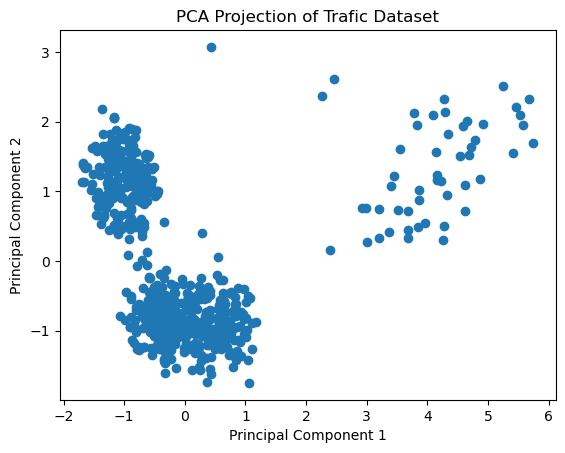

In [81]:
plt.figure()
plt.scatter(x_pca[:, 0], x_pca[:, 1])

plt.title("PCA Projection of Trafic Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
K-MEANS
</h1>
</div>

In [82]:
from sklearn.cluster import KMeans

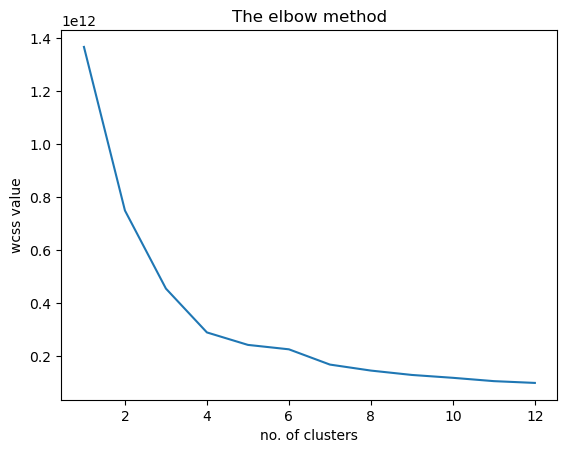

In [83]:
wcss=[]
for i in range(1,13):
    kmeans=KMeans(n_clusters=i,init='k-means++',
                  random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,13),wcss)
plt.title('The elbow method')
plt.xlabel('no. of clusters')
plt.ylabel('wcss value')
plt.show()

In [84]:
Kmean=KMeans(2,init='k-means++',random_state=42)
y_kmeans=Kmean.fit_predict(df)
y_kmeans

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [85]:
XSscore = silhouette_score(df, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.6296293800454943


<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
Hierarchical clustering
</h1>
</div>

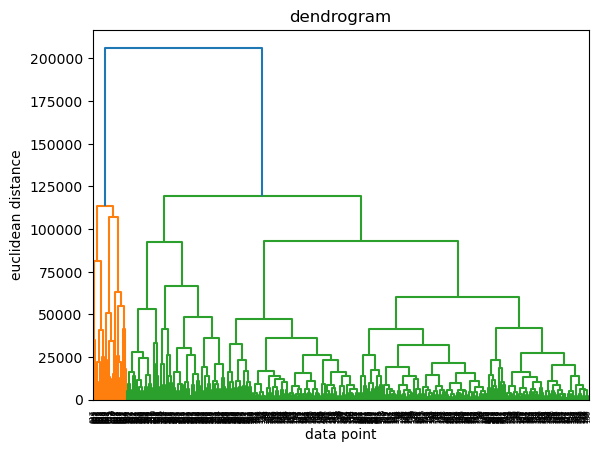

In [86]:
dendrogram=sch.dendrogram(sch.linkage(df,method='complete'))
plt.title('dendrogram')
plt.xlabel('data point')
plt.ylabel('euclidean distance')
plt.show()

In [87]:
ahc=AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
y_ahc=ahc.fit_predict(df)
y_ahc

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [88]:
sil_ahc=silhouette_score(df,y_ahc)
sil_ahc

np.float64(0.637757065356093)

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
DBSCAN
</h1>
</div>

In [89]:
epsilon = 0.8
min_samples=9
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(x_pca)

In [90]:
set(labels)

{np.int64(-1), np.int64(0), np.int64(1)}

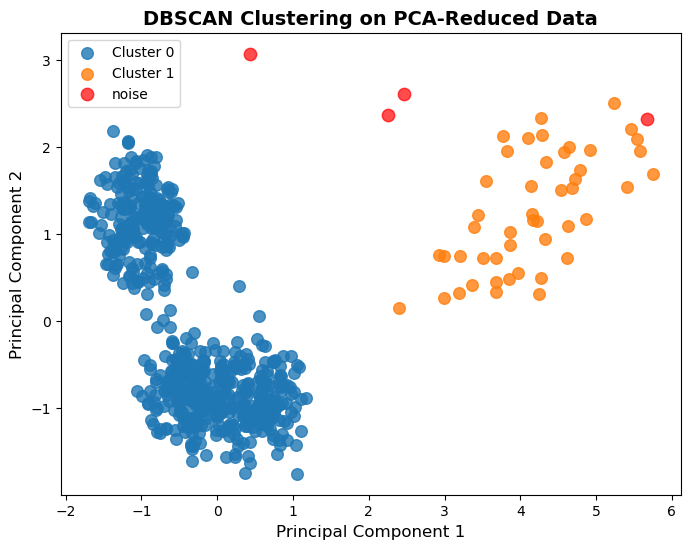

In [91]:
plt.figure(figsize=(8,6))
for i in set(labels):
    if i ==-1:
        plt.scatter(
            x_pca[labels==i,0],
            x_pca[labels==i,1],
            c='red',
            s=80,
            alpha=0.7,
            label='noise'
        ) 
    else:
        plt.scatter(
            x_pca[labels==i,0],
            x_pca[labels==i,1],
            s=70,
            alpha=0.8,
            label=f'Cluster {i}'
        )
plt.title("DBSCAN Clustering on PCA-Reduced Data", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend()
plt.show()


In [92]:
from sklearn.metrics import silhouette_score
sil_ahc1=silhouette_score(x_pca,labels)
sil_ahc1

np.float64(0.6453651822285025)

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
FUZZY
</h1>
</div>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

...

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

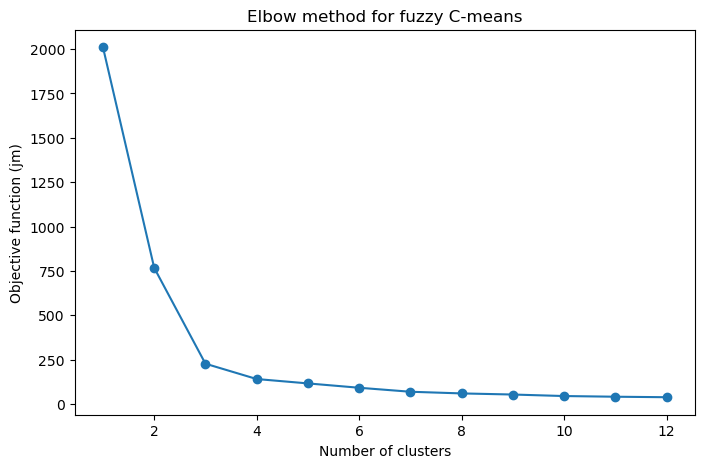

In [93]:
x = x_pca.T
cluster_range = range(1,13)

jm_values = []

for c in cluster_range:
    cntre, u, u0, d, jm, p, fpc = fuzz._cluster.cmeans(
        x,
        c=c,
        m=2.0,
        error=0.005,
        maxiter=1000,
        init=None
    )
    jm_values.append(jm[-1])
    plt.figure(figsize=(8,5))
plt.plot(cluster_range,jm_values,marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Objective function (jm)")
plt.title("Elbow method for fuzzy C-means")
plt.show()

In [94]:
n_clusters = 4
m = 3
error = 1e-5
maxiter = 1000

In [95]:
cntr, u, u0, d, jm, p, fpc = fuzz._cluster.cmeans(
    x_pca.T, c=c,m=2.0,error=0.005,maxiter=1000
)
u_transposed = u.T
hard_clusters = np.argmax(u_transposed, axis=1)

score4 = silhouette_score(x_pca,hard_clusters)
print("Silhouette_Score", score4)


Silhouette_Score 0.37015242774469415


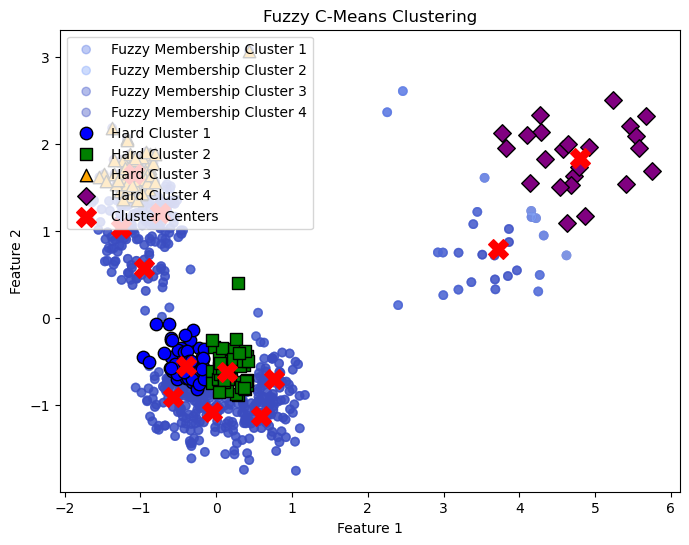

In [96]:
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_clusters):
    ax.scatter(
        x_pca[:, 0],
        x_pca[:, 1],
        c=u[i],  
        cmap='coolwarm',
        alpha=0.4,
        label=f'Fuzzy Membership Cluster {i+1}'
    )

markers = ['o', 's', '^', 'D', 'v'] 
colors = ['blue', 'green', 'orange', 'purple', 'brown']

for i in range(n_clusters):
    cluster_points = x_pca[hard_clusters == i]
    ax.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors[i],  
        marker=markers[i],
        edgecolor='k',
        s=80,
        label=f'Hard Cluster {i+1}'
    )

ax.scatter(
    cntr[:, 0], 
    cntr[:, 1],  
    c='red',     
    marker='X',  
    s=200,       
    label='Cluster Centers'
)

ax.set_title('Fuzzy C-Means Clustering')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

ax.legend(loc='upper left')

plt.show()

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
TABULATE
</h1>
</div>


In [97]:
from tabulate import tabulate

table = [
    ['Clustering Method', 'Silhouette Score'],
    ['KMeans', score],
    ['DBSCAN', sil_ahc1],
    ['Hierarchical clustering', sil_ahc],
    ['Fuzzy C-Means', score4],
   
]

print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

╒═════════════════════════╤════════════════════╕
│ Clustering Method       │   Silhouette Score │
╞═════════════════════════╪════════════════════╡
│ KMeans                  │           0.629629 │
├─────────────────────────┼────────────────────┤
│ DBSCAN                  │           0.645365 │
├─────────────────────────┼────────────────────┤
│ Hierarchical clustering │           0.637757 │
├─────────────────────────┼────────────────────┤
│ Fuzzy C-Means           │           0.370152 │
╘═════════════════════════╧════════════════════╛


<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
Clusterd Dataset
</h1>
</div>


In [98]:
df=pd.DataFrame(df)
df['Cluster']=labels

In [99]:
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,1,87073,100000,2,1,1,0,0
1,2,38414,50000,3,0,10,9,-1
2,3,17341,50000,7,1,3,4,0
3,4,40496,30000,5,1,1,4,0
4,5,47437,100000,6,0,12,3,-1
...,...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0,1
656,657,60732,84000,10,1,13,2,1
657,658,53834,145000,8,1,9,1,1
658,659,80655,172000,10,1,15,0,1


In [102]:
cluster_1=df.loc[df['Cluster']==0]
cluster_1.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,1,87073,100000,2,1,1,0,0
2,3,17341,50000,7,1,3,4,0
3,4,40496,30000,5,1,1,4,0
5,6,58634,20000,3,0,1,8,0
7,8,37376,15000,3,0,1,1,0


In [103]:
cluster_1.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
count,609.000000,609.000000,609.000000,609.000000,609.000000,609.000000,609.000000,609.0
mean,307.986864,55040.231527,25807.881773,4.377668,2.555008,1.912972,3.779967,0.0
std,175.970167,25554.823901,20717.576212,1.873963,1.602017,1.563559,2.869565,0.0
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000,0.0
25%,156.000000,33991.000000,10000.000000,3.000000,1.000000,1.000000,1.000000,0.0
50%,308.000000,53898.000000,17000.000000,4.000000,2.000000,2.000000,3.000000,0.0
75%,460.000000,76718.000000,39000.000000,6.000000,4.000000,3.000000,6.000000,0.0
max,612.000000,99596.000000,100000.000000,7.000000,5.000000,5.000000,10.000000,0.0


In [105]:
cluster_2=df.loc[df['Cluster']==1]
cluster_2.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
612,613,94391,157000,9,1,14,1,1
613,614,50598,94000,9,1,11,0,1
614,615,40019,163000,8,1,7,1,1
615,616,77910,131000,9,1,10,1,1
616,617,89832,96000,10,1,11,2,1


In [106]:
cluster_2.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.0
mean,636.595745,57972.659574,141638.297872,8.893617,0.638298,10.787234,1.042553,1.0
std,14.135462,26937.896618,33584.044822,1.107956,0.485688,2.903792,0.832948,0.0
min,613.000000,13315.000000,84000.000000,7.000000,0.000000,6.000000,0.000000,1.0
25%,624.500000,33210.500000,111500.000000,8.000000,0.000000,8.000000,0.000000,1.0
50%,637.000000,54495.000000,146000.000000,9.000000,1.000000,11.000000,1.000000,1.0
75%,648.500000,80051.500000,169000.000000,10.000000,1.000000,13.000000,2.000000,1.0
max,660.000000,99843.000000,200000.000000,10.000000,1.000000,15.000000,2.000000,1.0


| Cluster    | No. of Customers | Customer Type                    | Key Characteristics                                                                 | Business Insight                                                                 |
|------------|------------------|-----------------------------------|--------------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| Cluster 1  | 609              | Low to Medium Value Customers     | - Lower average credit limit <br> - Fewer credit cards <br> - More bank visits <br> - Less online usage <br> - More customer service calls | - Depend more on offline banking <br> - Need more guidance and support <br> - Suitable for digital banking awareness programs |
| Cluster 2  | 51               | High-Value / Premium Customers    | - Very high credit limit <br> - Many credit cards <br> - Rare bank visits <br> - High online usage <br> - Very few calls | - Digitally active and independent <br> - Comfortable with online services <br> - Ideal for premium offers and loyalty programs |
